In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/anshgoel0110/loan-approval-project/Loan.csv


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/kaggle/input/datasets/anshgoel0110/loan-approval-project/Loan.csv")

In [4]:
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

In [6]:
df.isnull().sum()

ApplicationDate               0
Age                           0
AnnualIncome                  0
CreditScore                   0
EmploymentStatus              0
EducationLevel                0
Experience                    0
LoanAmount                    0
LoanDuration                  0
MaritalStatus                 0
NumberOfDependents            0
HomeOwnershipStatus           0
MonthlyDebtPayments           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
DebtToIncomeRatio             0
BankruptcyHistory             0
LoanPurpose                   0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
TotalAssets                   0
TotalLiabilities              0
MonthlyIncome                 0
UtilityBillsPaymentHistory    0
JobTenure                     0
NetWorth                      0
BaseInterestRate              0
Interest

In [7]:
df.describe()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,59161.473550,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,40350.845168,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,15000.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,31679.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,48566.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,74391.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,485341.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


# Handle Missing Values

In [8]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

categorical_columns = df.select_dtypes(include=['object']).columns

In [9]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(
    strategy = "mean"
)
df[numerical_columns] = num_imp.fit_transform(df[numerical_columns])

In [10]:
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45.0,39948.0,617.0,Employed,Master,22.0,13152.0,48.0,Married,...,3329.000000,0.724972,11.0,126928.0,0.199652,0.227590,419.805992,0.181077,0.0,49.0
1,2018-01-02,38.0,39709.0,628.0,Employed,Associate,15.0,26045.0,48.0,Single,...,3309.083333,0.935132,3.0,43609.0,0.207045,0.201077,794.054238,0.389852,0.0,52.0
2,2018-01-03,47.0,40724.0,570.0,Employed,Bachelor,26.0,17627.0,36.0,Married,...,3393.666667,0.872241,6.0,5205.0,0.217627,0.212548,666.406688,0.462157,0.0,52.0
3,2018-01-04,58.0,69084.0,545.0,Employed,High School,34.0,37898.0,96.0,Single,...,5757.000000,0.896155,5.0,99452.0,0.300398,0.300911,1047.506980,0.313098,0.0,54.0
4,2018-01-05,37.0,103264.0,594.0,Employed,Associate,17.0,9184.0,36.0,Married,...,8605.333333,0.941369,5.0,227019.0,0.197184,0.175990,330.179140,0.070210,1.0,36.0


In [11]:
cat_imp = SimpleImputer(
    strategy = "most_frequent"
)
df[categorical_columns] = cat_imp.fit_transform(df[categorical_columns])

# EDA - Exploratory Data Analysis

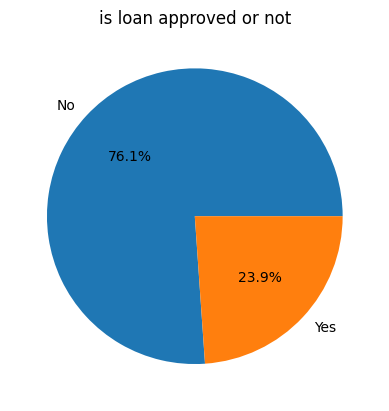

In [12]:
classes_count = df["LoanApproved"].value_counts()

plt.pie(classes_count, labels=["No","Yes"], autopct="%1.1f%%")
plt.title("is loan approved or not")
plt.savefig("loan_approval_distribution.png", dpi=300, bbox_inches="tight")

[Text(0, 0, '10041'),
 Text(0, 0, '6078'),
 Text(0, 0, '2882'),
 Text(0, 0, '999')]

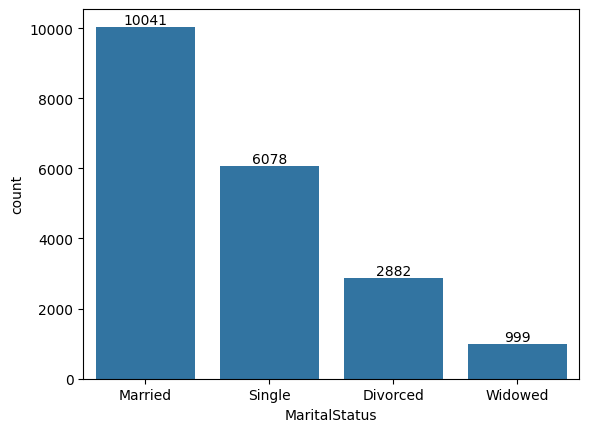

In [13]:
gend_count = df["MaritalStatus"].value_counts()
ax = sns.barplot(gend_count)
ax.bar_label(ax.containers[0])

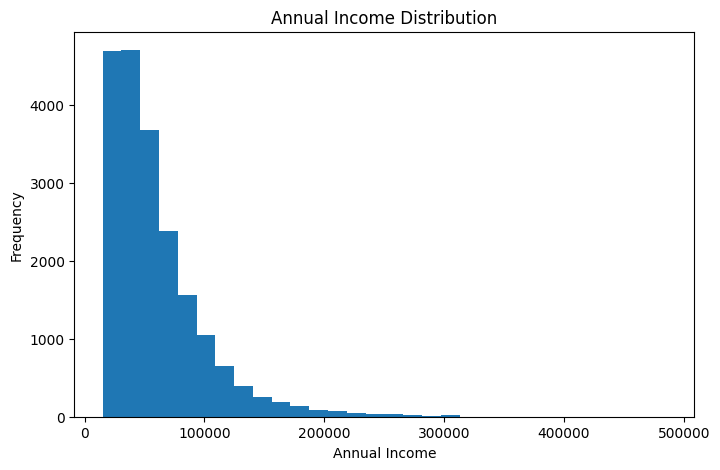

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df["AnnualIncome"], bins=30)

plt.title("Annual Income Distribution")

plt.xlabel("Annual Income")

plt.ylabel("Frequency")

plt.show()

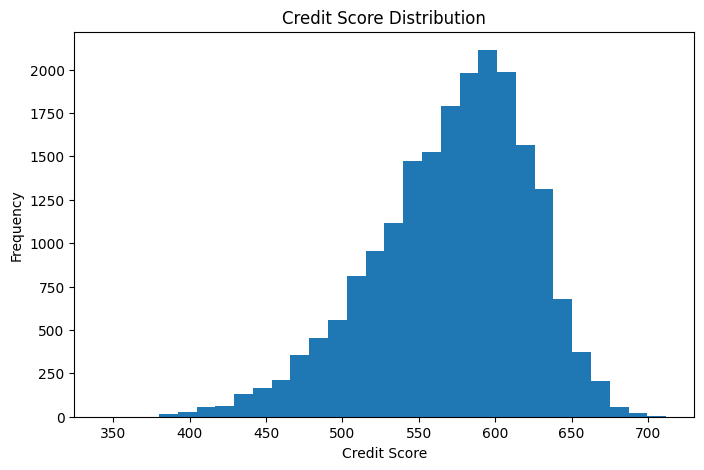

In [15]:
plt.figure(figsize=(8,5))

plt.hist(df["CreditScore"], bins=30)

plt.title("Credit Score Distribution")

plt.xlabel("Credit Score")

plt.ylabel("Frequency")

plt.show()

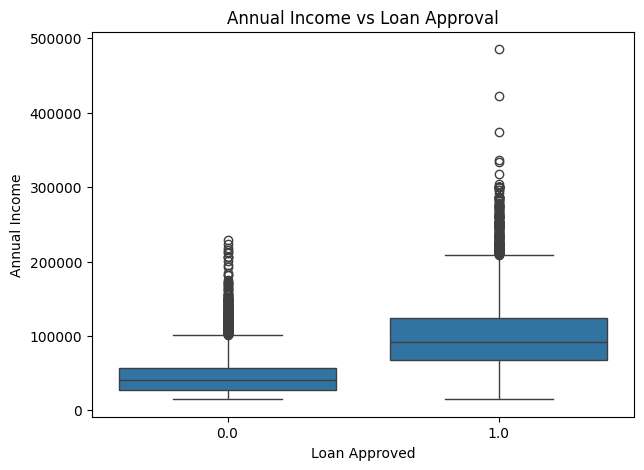

In [16]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="LoanApproved",
    y="AnnualIncome"
)

plt.title("Annual Income vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Annual Income")
plt.show()

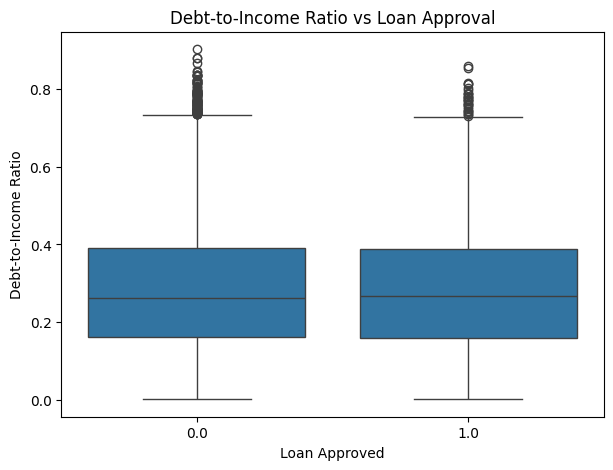

In [17]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="LoanApproved",
    y="DebtToIncomeRatio"
)

plt.title("Debt-to-Income Ratio vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Debt-to-Income Ratio")
plt.savefig("dti_vs_approval.png", dpi=300, bbox_inches="tight")
plt.show()

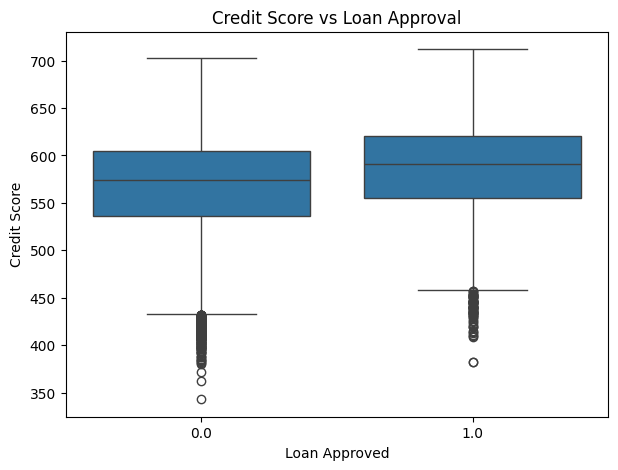

In [18]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="LoanApproved",
    y="CreditScore"
)

plt.title("Credit Score vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Credit Score")
plt.savefig("credit_score_vs_approval.png", dpi=300, bbox_inches="tight")
plt.show()

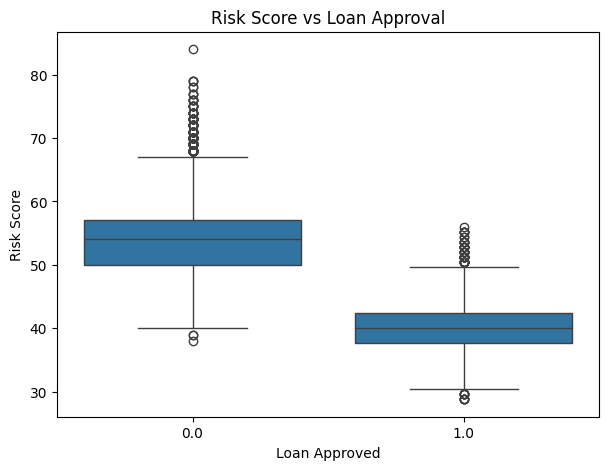

In [19]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="LoanApproved",
    y="RiskScore"
)

plt.title("Risk Score vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Risk Score")
plt.show()

<Axes: xlabel='CreditScore', ylabel='Count'>

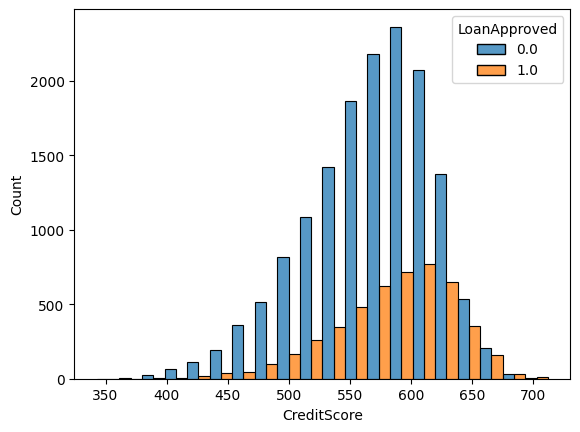

In [20]:
sns.histplot(
    data = df,
    x = "CreditScore",
    hue = "LoanApproved",
    bins = 20,
    multiple = "dodge"
)

# Feature Encoding

In [21]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  float64
 2   AnnualIncome                20000 non-null  float64
 3   CreditScore                 20000 non-null  float64
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  float64
 7   LoanAmount                  20000 non-null  float64
 8   LoanDuration                20000 non-null  float64
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  float64
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  float64
 13  CreditCardUtilizationRate   200

In [23]:
ohe = OneHotEncoder(drop = "first", sparse_output = False, handle_unknown = "ignore")

cols = ["EmploymentStatus","EducationLevel","LoanPurpose","HomeOwnershipStatus","MaritalStatus"]
encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded ,columns=ohe.get_feature_names_out(cols),index = df.index)

df = pd.concat([df.drop(columns=cols), encoded_df], axis = 1)

In [24]:
df = df.drop("ApplicationDate",axis=1)

In [25]:
df.head()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HomeOwnershipStatus_Other,HomeOwnershipStatus_Own,HomeOwnershipStatus_Rent,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed
0,45.0,39948.0,617.0,22.0,13152.0,48.0,2.0,183.0,0.354418,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,38.0,39709.0,628.0,15.0,26045.0,48.0,1.0,496.0,0.087827,5.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,47.0,40724.0,570.0,26.0,17627.0,36.0,2.0,902.0,0.137414,2.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,58.0,69084.0,545.0,34.0,37898.0,96.0,1.0,755.0,0.267587,2.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,37.0,103264.0,594.0,17.0,9184.0,36.0,1.0,274.0,0.320535,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# Correlation HeatMap

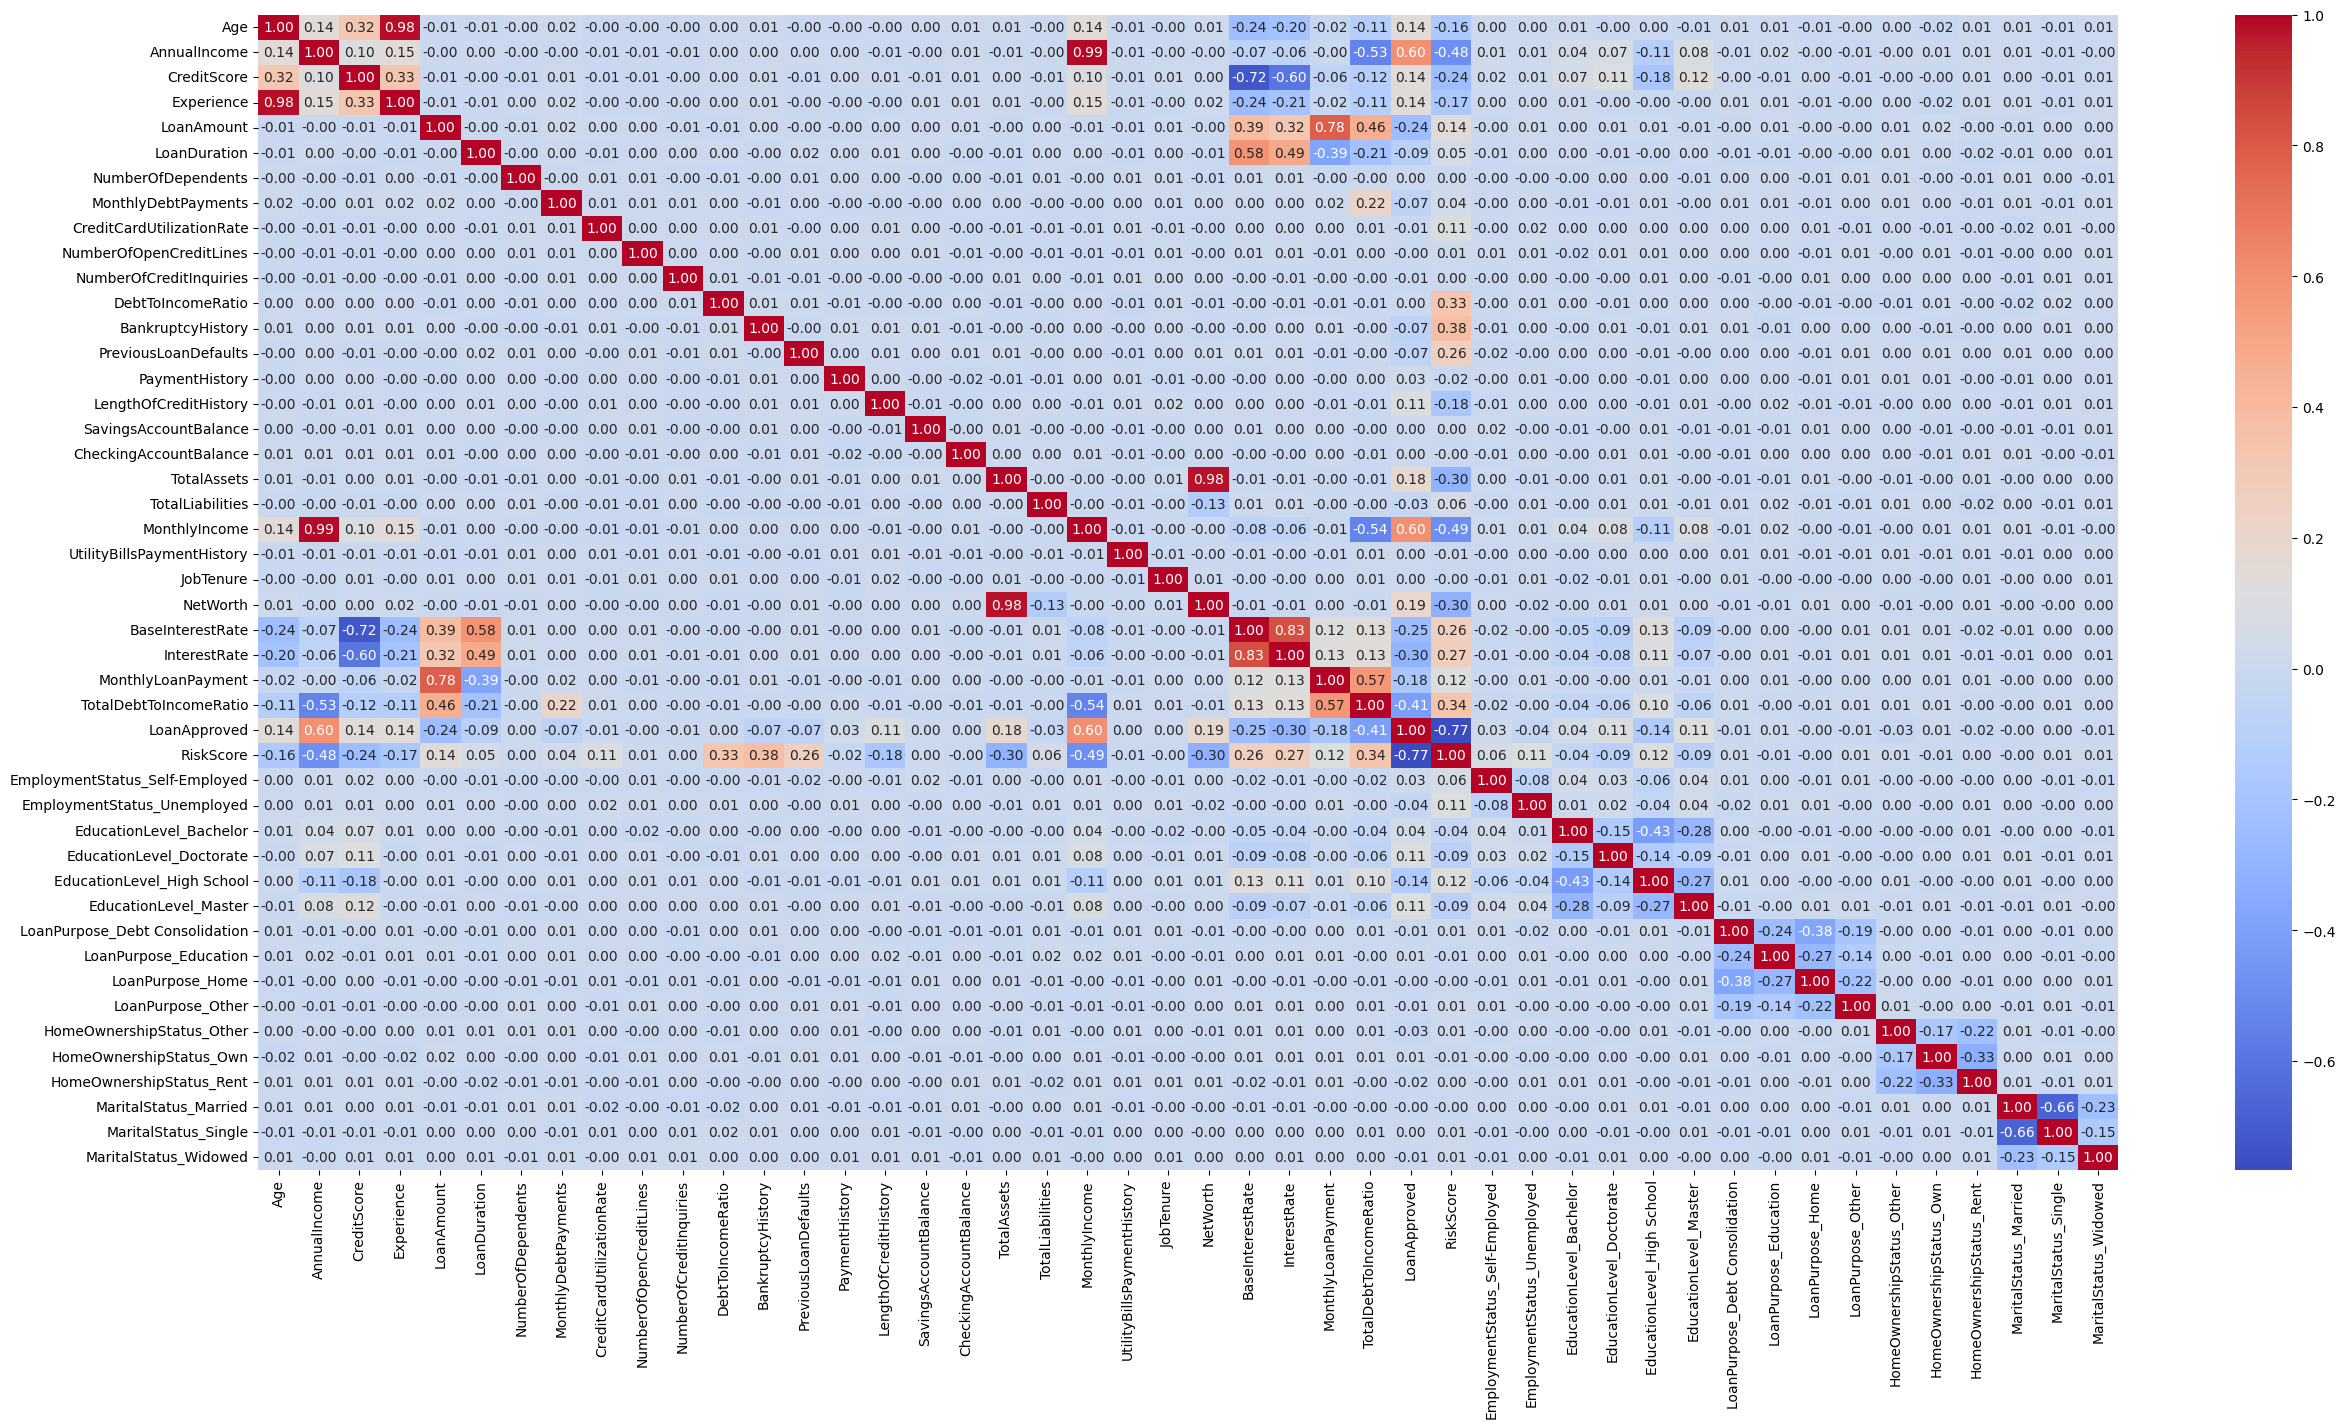

In [26]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

plt.figure(figsize=(30,15))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")

In [27]:
num_cols.corr()["LoanApproved"].sort_values(ascending=False)

LoanApproved                      1.000000
MonthlyIncome                     0.604101
AnnualIncome                      0.597900
NetWorth                          0.187892
TotalAssets                       0.184011
CreditScore                       0.142000
Age                               0.141029
Experience                        0.140755
EducationLevel_Master             0.111222
LengthOfCreditHistory             0.105949
EducationLevel_Doctorate          0.105614
EducationLevel_Bachelor           0.042385
PaymentHistory                    0.030804
EmploymentStatus_Self-Employed    0.027026
LoanPurpose_Education             0.013804
HomeOwnershipStatus_Own           0.011445
JobTenure                         0.004997
UtilityBillsPaymentHistory        0.003303
NumberOfDependents                0.001717
SavingsAccountBalance             0.000961
CheckingAccountBalance            0.000660
MaritalStatus_Single              0.000601
DebtToIncomeRatio                 0.000034
MaritalStat

# Train Test Split - Feature Scaling

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X = df.drop("LoanApproved", axis=1)
y = df["LoanApproved"]

In [30]:
X.head()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HomeOwnershipStatus_Other,HomeOwnershipStatus_Own,HomeOwnershipStatus_Rent,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed
0,45.0,39948.0,617.0,22.0,13152.0,48.0,2.0,183.0,0.354418,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,38.0,39709.0,628.0,15.0,26045.0,48.0,1.0,496.0,0.087827,5.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,47.0,40724.0,570.0,26.0,17627.0,36.0,2.0,902.0,0.137414,2.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,58.0,69084.0,545.0,34.0,37898.0,96.0,1.0,755.0,0.267587,2.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,37.0,103264.0,594.0,17.0,9184.0,36.0,1.0,274.0,0.320535,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [31]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [32]:
X_train.head()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HomeOwnershipStatus_Other,HomeOwnershipStatus_Own,HomeOwnershipStatus_Rent,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed
5894,45.0,15000.0,620.0,21.0,17419.0,36.0,3.0,519.0,0.368528,3.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3728,25.0,49855.0,486.0,3.0,18998.0,48.0,5.0,404.0,0.148286,2.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
8958,51.0,38932.0,576.0,30.0,17844.0,72.0,1.0,491.0,0.411293,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
7671,18.0,58116.0,516.0,0.0,24050.0,60.0,0.0,831.0,0.141719,3.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5999,25.0,62939.0,562.0,3.0,27263.0,36.0,0.0,766.0,0.232934,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
X_train_scaled

array([[ 0.44626865, -1.09471338,  0.94883443, ...,  0.9900495 ,
        -0.65718755, -0.23346244],
       [-1.27453396, -0.22573729, -1.68545498, ...,  0.9900495 ,
        -0.65718755, -0.23346244],
       [ 0.96250943, -0.49806051,  0.08384388, ...,  0.9900495 ,
        -0.65718755, -0.23346244],
       ...,
       [-0.75829318, -0.26979067, -1.07602982, ...,  0.9900495 ,
        -0.65718755, -0.23346244],
       [ 0.18814825, -1.08810662,  0.67361016, ...,  0.9900495 ,
        -0.65718755, -0.23346244],
       [-0.2420524 , -0.3418667 ,  1.16508207, ..., -1.0100505 ,
        -0.65718755, -0.23346244]])

# Train & Evaluate Model

In [35]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

#Evaluation
lg_metrics = {
"model": "Logistic Regression Model",
"Precision": precision_score(y_test,y_pred),
"Recall": recall_score(y_test,y_pred),
"f1 score": f1_score(y_test,y_pred),
"Accuracy": accuracy_score(y_test,y_pred)
}
lg_cm = confusion_matrix(y_test,y_pred)

In [36]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

#Evaluation
knn_metrics = {
"model": "KNN Model",
"Precision": precision_score(y_test,y_pred_knn),
"Recall": recall_score(y_test,y_pred_knn),
"f1 score": f1_score(y_test,y_pred_knn),
"Accuracy": accuracy_score(y_test,y_pred_knn)
}
knn_cm = confusion_matrix(y_test,y_pred_knn)

In [37]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred_nb = nb_model.predict(X_test_scaled)

#Evaluation
nb_metrics = {
"model": "Naive Baiyes Model",
"Precision": precision_score(y_test,y_pred_nb),
"Recall": recall_score(y_test,y_pred_nb),
"f1 score": f1_score(y_test,y_pred_nb),
"Accuracy": accuracy_score(y_test,y_pred_nb)
}
nb_cm = confusion_matrix(y_test,y_pred_nb)

In [38]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier

dtc_model = DecisionTreeClassifier(random_state=42,max_depth=8)
dtc_model.fit(X_train_scaled, y_train)

y_pred_dtc = dtc_model.predict(X_test_scaled)

#Evaluation
dtc_metrics = {
"model": "Decision Tree Classifier Model",
"Precision": precision_score(y_test,y_pred_dtc),
"Recall": recall_score(y_test,y_pred_dtc),
"f1 score": f1_score(y_test,y_pred_dtc),
"Accuracy": accuracy_score(y_test,y_pred_dtc)
}
dtc_cm = confusion_matrix(y_test,y_pred_dtc)

In [39]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rfc_model = RandomForestClassifier(n_estimators=200,
    random_state=42,
    n_jobs=-1)
rfc_model.fit(X_train_scaled, y_train)

y_pred_rfc = rfc_model.predict(X_test_scaled)

#Evaluation
rfc_metrics = {
"model": "Random Forest Classifier Model",
"Precision": precision_score(y_test,y_pred_rfc),
"Recall": recall_score(y_test,y_pred_rfc),
"f1 score": f1_score(y_test,y_pred_rfc),
"Accuracy": accuracy_score(y_test,y_pred_rfc)
}
rfc_cm = confusion_matrix(y_test,y_pred_rfc)

In [40]:
#Support Vector Machine
from sklearn.svm import SVC

svm_model = SVC(
    probability=True,
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

#Evaluation
svm_metrics = {
"model": "Support Vector Machine Model",
"Precision": precision_score(y_test,y_pred_svm),
"Recall": recall_score(y_test,y_pred_svm),
"f1 score": f1_score(y_test,y_pred_svm),
"Accuracy": accuracy_score(y_test,y_pred_svm)
}
svm_cm = confusion_matrix(y_test,y_pred_svm)

In [41]:
#Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier

gbc_model = GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
gbc_model.fit(X_train_scaled, y_train)

y_pred_gbc = gbc_model.predict(X_test_scaled)

#Evaluation
gradient_metrics = {
"model": "Gradient Boost Classifier Model",
"Precision": precision_score(y_test,y_pred_gbc),
"Recall": recall_score(y_test,y_pred_gbc),
"f1 score": f1_score(y_test,y_pred_gbc),
"Accuracy": accuracy_score(y_test,y_pred_gbc)
}
gradient_cm = confusion_matrix(y_test,y_pred_gbc)

In [42]:
#XGBClassifier
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

#Evaluation
xgboost_metrics = {
"model": "XGBoost Classifier Model",
"Precision": precision_score(y_test,y_pred_xgb),
"Recall": recall_score(y_test,y_pred_xgb),
"f1 score": f1_score(y_test,y_pred_xgb),
"Accuracy": accuracy_score(y_test,y_pred_xgb)
}
xgboost_cm = confusion_matrix(y_test,y_pred_xgb)

In [43]:
#CATBoostClassifier
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0
)
catboost_model.fit(X_train_scaled, y_train)
y_pred_cat = catboost_model.predict(X_test_scaled)

#Evaluation
catboost_metrics = {
"model": "CATBoost Classifier Model",
"Precision": precision_score(y_test,y_pred_cat),
"Recall": recall_score(y_test,y_pred_cat),
"f1 score": f1_score(y_test,y_pred_cat),
"Accuracy": accuracy_score(y_test,y_pred_cat)
}
catboost_cm = confusion_matrix(y_test,y_pred_cat)

In [44]:
all_model_metrics = [
    lg_metrics,
    knn_metrics,
    nb_metrics,
    dtc_metrics,
    rfc_metrics,
    svm_metrics,
    gradient_metrics,
    xgboost_metrics,
    catboost_metrics
]

results_df = pd.DataFrame(all_model_metrics)

results_df

,model,Precision,Recall,f1 score,Accuracy
0,Logistic Regression Model,1.000000,1.000000,1.000000,1.00000
1,KNN Model,0.921279,0.736480,0.818579,0.91700
2,Naive Baiyes Model,0.876700,0.950836,0.912264,0.95350
3,Decision Tree Classifier Model,0.988012,0.972468,0.980178,0.99000
4,Random Forest Classifier Model,0.987154,0.982301,0.984722,0.99225
5,Support Vector Machine Model,1.000000,0.996067,0.998030,0.99900
6,Gradient Boost Classifier Model,0.998033,0.998033,0.998033,0.99900
7,XGBoost Classifier Model,0.998035,0.999017,0.998526,0.99925
8,CATBoost Classifier Model,1.000000,1.000000,1.000000,1.00000


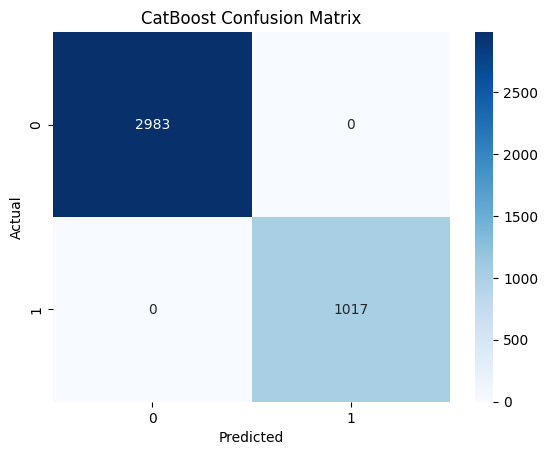

In [45]:
sns.heatmap(
    catboost_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("CatBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<Figure size 1200x600 with 0 Axes>

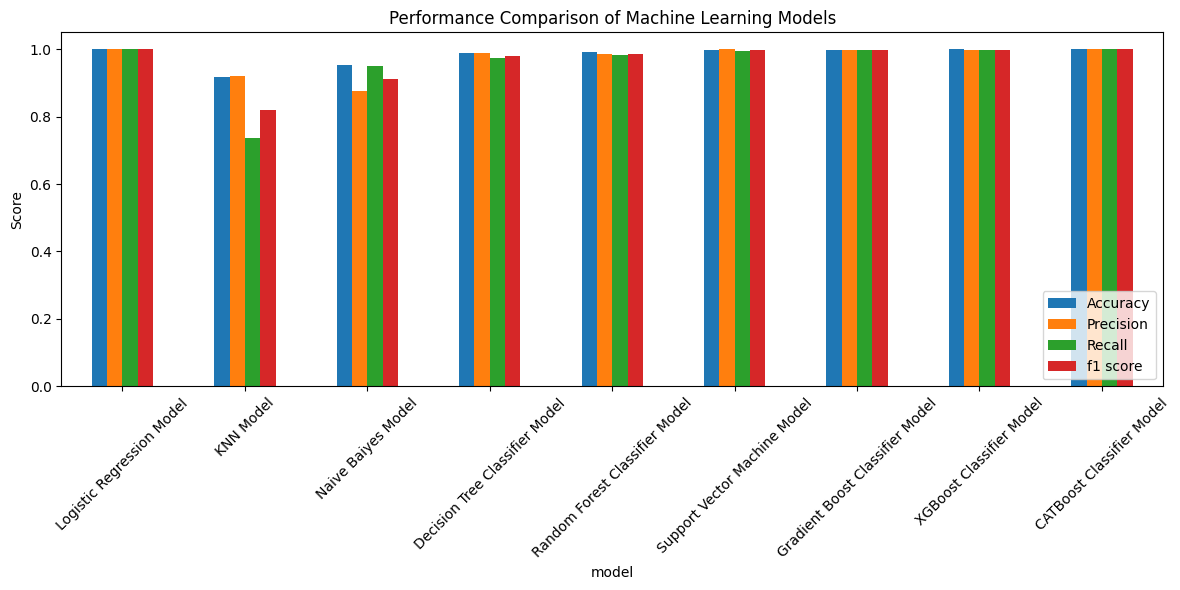

In [46]:
plt.figure(figsize=(12, 6))

results_plot = results_df.set_index("model")[
    ["Accuracy", "Precision", "Recall", "f1 score"]
]

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Performance Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("performance comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Feature Engineering

In [47]:
#Add or Transform Data
df["DebtToIncomeRatio_sq"] = df["DebtToIncomeRatio"] ** 2
df["CreditScore_sq"] = df["CreditScore"] ** 2

X = df.drop(columns=["LoanApproved", "CreditScore", "DebtToIncomeRatio"])
y = df["LoanApproved"]

#Train test split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

#scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
X_train.head()

,Age,AnnualIncome,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,...,LoanPurpose_Home,LoanPurpose_Other,HomeOwnershipStatus_Other,HomeOwnershipStatus_Own,HomeOwnershipStatus_Rent,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,DebtToIncomeRatio_sq,CreditScore_sq
5894,45.0,15000.0,21.0,17419.0,36.0,3.0,519.0,0.368528,3.0,2.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.088308,384400.0
3728,25.0,49855.0,3.0,18998.0,48.0,5.0,404.0,0.148286,2.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.581481,236196.0
8958,51.0,38932.0,30.0,17844.0,72.0,1.0,491.0,0.411293,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.016558,331776.0
7671,18.0,58116.0,0.0,24050.0,60.0,0.0,831.0,0.141719,3.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.095310,266256.0
5999,25.0,62939.0,3.0,27263.0,36.0,0.0,766.0,0.232934,3.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.216948,315844.0


In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

#Evaluation
lg_metrics = {
"model": "Logistic Regression Model",
"Precision": precision_score(y_test,y_pred),
"Recall": recall_score(y_test,y_pred),
"f1 score": f1_score(y_test,y_pred),
"Accuracy": accuracy_score(y_test,y_pred)
}
lg_cm = confusion_matrix(y_test,y_pred)

In [50]:
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0
)
catboost_model.fit(X_train_scaled, y_train)
y_pred_cat = catboost_model.predict(X_test_scaled)

#Evaluation
catboost_metrics = {
"model": "CATBoost Classifier Model",
"Precision": precision_score(y_test,y_pred_cat),
"Recall": recall_score(y_test,y_pred_cat),
"f1 score": f1_score(y_test,y_pred_cat),
"Accuracy": accuracy_score(y_test,y_pred_cat)
}
catboost_cm = confusion_matrix(y_test,y_pred_cat)

In [51]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

#Evaluation
xgboost_metrics = {
"model": "XGBoost Classifier Model",
"Precision": precision_score(y_test,y_pred_xgb),
"Recall": recall_score(y_test,y_pred_xgb),
"f1 score": f1_score(y_test,y_pred_xgb),
"Accuracy": accuracy_score(y_test,y_pred_xgb)
}
xgboost_cm = confusion_matrix(y_test,y_pred_xgb)

In [52]:
from sklearn.svm import SVC

svm_model = SVC(
    probability=True,
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

#Evaluation
svm_metrics = {
"model": "Support Vector Machine Model",
"Precision": precision_score(y_test,y_pred_svm),
"Recall": recall_score(y_test,y_pred_svm),
"f1 score": f1_score(y_test,y_pred_svm),
"Accuracy": accuracy_score(y_test,y_pred_svm)
}
svm_cm = confusion_matrix(y_test,y_pred_svm)

In [53]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred_nb = nb_model.predict(X_test_scaled)

#Evaluation
nb_metrics = {
"model": "Naive Baiyes Model",
"Precision": precision_score(y_test,y_pred_nb),
"Recall": recall_score(y_test,y_pred_nb),
"f1 score": f1_score(y_test,y_pred_nb),
"Accuracy": accuracy_score(y_test,y_pred_nb)
}
nb_cm = confusion_matrix(y_test,y_pred_nb)

In [54]:
feature_engineered_metrics = [
    lg_metrics,
    nb_metrics,
    svm_metrics,
    xgboost_metrics,
    catboost_metrics
]

results_df = pd.DataFrame(feature_engineered_metrics)

results_df

,model,Precision,Recall,f1 score,Accuracy
0,Logistic Regression Model,0.998037,1.000000,0.999018,0.99950
1,Naive Baiyes Model,0.877495,0.950836,0.912695,0.95375
2,Support Vector Machine Model,1.000000,0.997050,0.998523,0.99925
3,XGBoost Classifier Model,0.998035,0.999017,0.998526,0.99925
4,CATBoost Classifier Model,1.000000,1.000000,1.000000,1.00000


# 5-Fold CrossValidation

In [55]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [56]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [57]:
cv_results = cross_validate(
    catboost_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1"
    },
    n_jobs=-1
)

In [58]:
print("CatBoost 5-Fold Cross-Validation Results")

print("Mean Accuracy:",
      cv_results["test_accuracy"].mean())

print("Mean Precision:",
      cv_results["test_precision"].mean())

print("Mean Recall:",
      cv_results["test_recall"].mean())

print("Mean F1 Score:",
      cv_results["test_f1"].mean())

print("F1 Standard Deviation:",
      cv_results["test_f1"].std())

CatBoost 5-Fold Cross-Validation Results
Mean Accuracy: 0.999625
Mean Precision: 0.9989386397821622
Mean Recall: 0.999468791500664
Mean F1 Score: 0.9992031871338882
F1 Standard Deviation: 0.0004969000983119561


In [59]:
catboost_cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Mean Score": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean()
    ]
})

catboost_cv_summary

,Metric,Mean Score
0,Accuracy,0.999625
1,Precision,0.998939
2,Recall,0.999469
3,F1 Score,0.999203


# Saving Best Model - CATBoost 

In [60]:
import joblib

joblib.dump(
    catboost_model,
    "final_catboost_model.pkl"
)

['final_catboost_model.pkl']

In [61]:
joblib.dump(
    scaler,
    "final_scaler.pkl"
)

['final_scaler.pkl']

In [62]:
import os

print("CatBoost Model:", os.path.exists("final_catboost_model.pkl"))
print("Scaler:", os.path.exists("final_scaler.pkl"))

CatBoost Model: True
Scaler: True


# XAI

In [63]:
import shap
from lime.lime_tabular import LimeTabularExplainer

In [64]:
shap_explainer = shap.TreeExplainer(catboost_model)

shap_values = shap_explainer.shap_values(X_test_scaled)

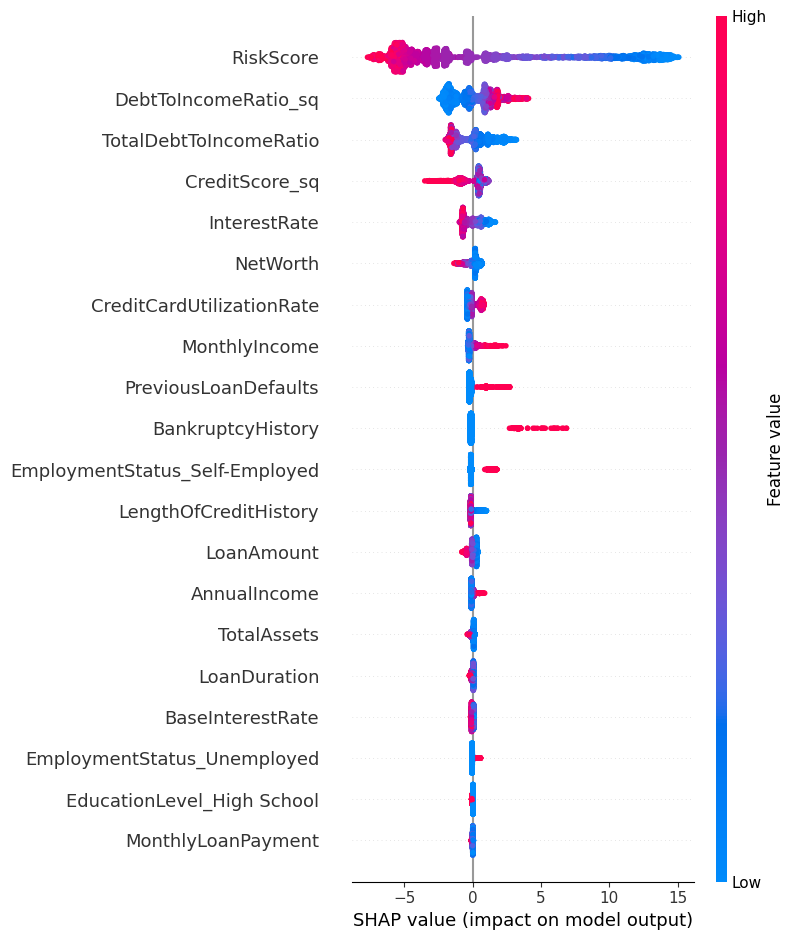

In [65]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns
)

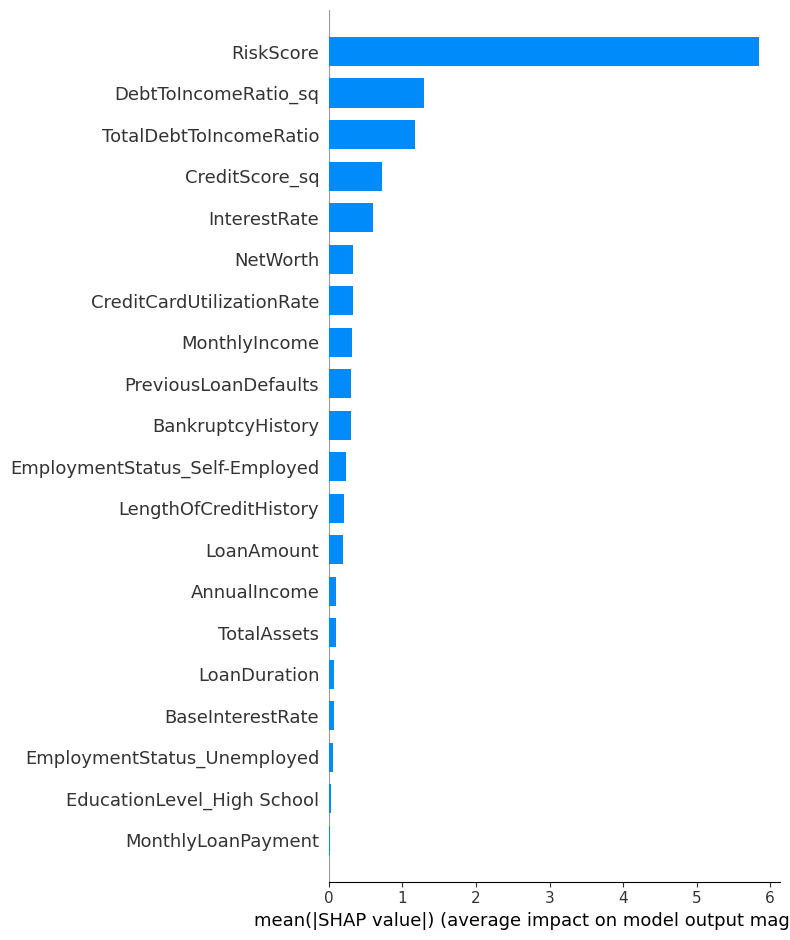

In [66]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns,
    plot_type="bar"
)

In [67]:
lime_explainer = LimeTabularExplainer(
    X_train_scaled,
    feature_names=X.columns.tolist(),
    class_names=["Rejected", "Approved"],
    mode="classification",
    random_state=42
)

In [68]:
approved_index = next(
    i for i, value in enumerate(y_test)
    if value == 1
)

rejected_index = next(
    i for i, value in enumerate(y_test)
    if value == 0
)

approved_sample = X_test_scaled[approved_index]
rejected_sample = X_test_scaled[rejected_index]

print("Approved applicant index:", approved_index)
print("Rejected applicant index:", rejected_index)

Approved applicant index: 0
Rejected applicant index: 2


In [69]:
approved_shap_exp = shap.Explanation(
    values=shap_values[approved_index],
    base_values=shap_explainer.expected_value,
    data=approved_sample,
    feature_names=X.columns
)

rejected_shap_exp = shap.Explanation(
    values=shap_values[rejected_index],
    base_values=shap_explainer.expected_value,
    data=rejected_sample,
    feature_names=X.columns
)

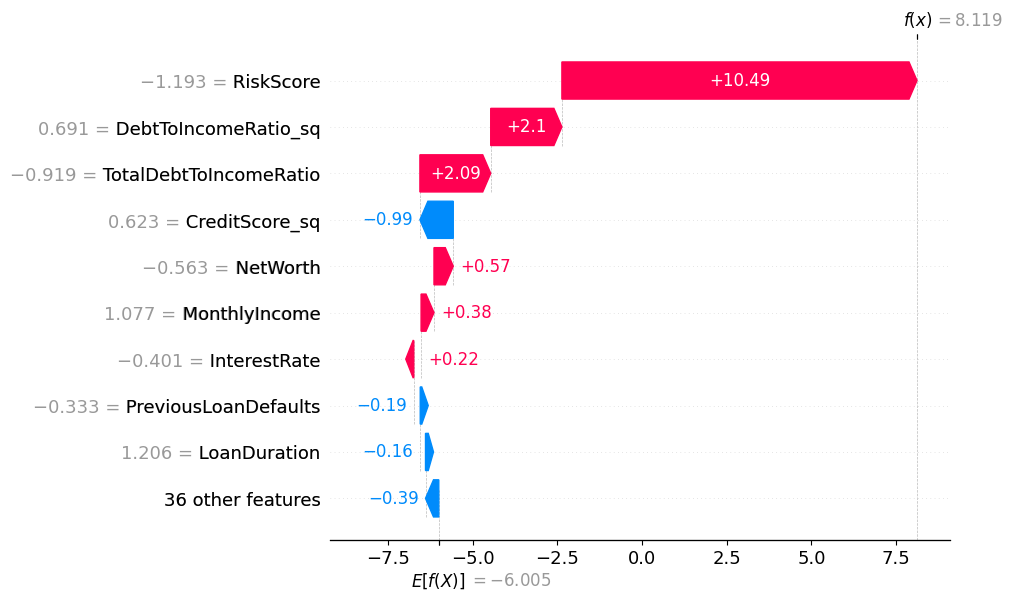

<Figure size 640x480 with 0 Axes>

In [70]:
shap.plots.waterfall(
    approved_shap_exp,
    max_display=10
)

plt.tight_layout()
plt.show()

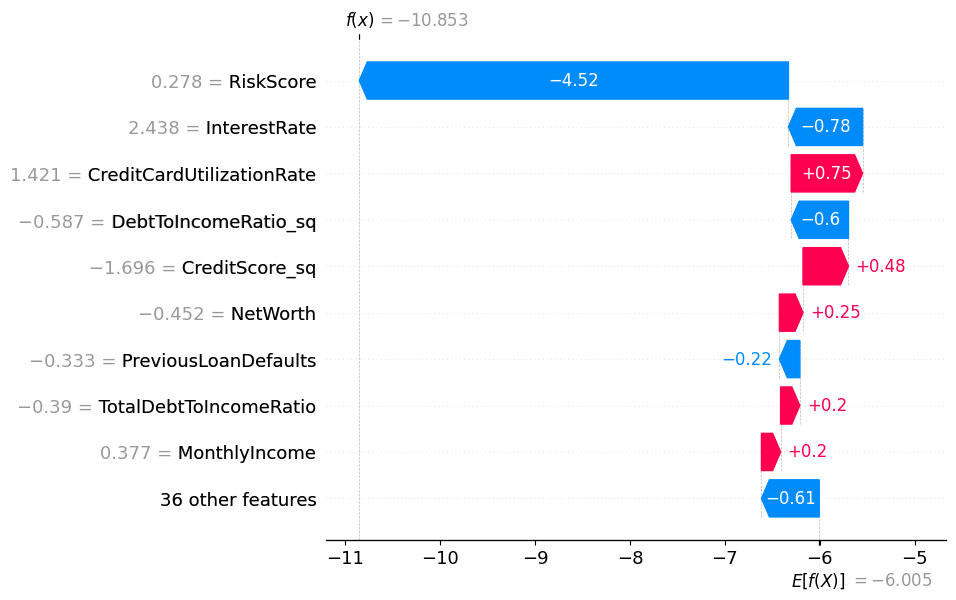

<Figure size 640x480 with 0 Axes>

In [71]:
shap.plots.waterfall(
    rejected_shap_exp,
    max_display=10
)

plt.tight_layout()
plt.show()

In [72]:
approved_lime_exp = lime_explainer.explain_instance(
    approved_sample,
    catboost_model.predict_proba,
    num_features=10
)

rejected_lime_exp = lime_explainer.explain_instance(
    rejected_sample,
    catboost_model.predict_proba,
    num_features=10
)

In [73]:
approved_lime_exp.show_in_notebook(show_table=True)

In [74]:
rejected_lime_exp.show_in_notebook(show_table=True)

In [75]:
def compare_shap_lime(index, lime_exp):

    shap_df = pd.DataFrame({
        "Feature": X.columns,
        "SHAP_Value": shap_values[index]
    })

    shap_df["Absolute_SHAP"] = shap_df["SHAP_Value"].abs()

    shap_df = shap_df.sort_values(
        "Absolute_SHAP",
        ascending=False
    ).head(10)

    lime_data = []

    for condition, contribution in lime_exp.as_list():

        feature = next(
            (column for column in X.columns if column in condition),
            None
        )

        if feature is not None:
            lime_data.append(
                [feature, contribution]
            )

    lime_df = pd.DataFrame(
        lime_data,
        columns=["Feature", "LIME_Contribution"]
    )

    comparison = pd.merge(
        shap_df[["Feature", "SHAP_Value"]],
        lime_df,
        on="Feature",
        how="inner"
    )

    comparison["Direction_Agreement"] = (
        comparison["SHAP_Value"] *
        comparison["LIME_Contribution"] > 0
    )

    return comparison

In [76]:
approved_comparison = compare_shap_lime(
    approved_index,
    approved_lime_exp
)

print("APPROVED APPLICANT")
approved_comparison

APPROVED APPLICANT


,Feature,SHAP_Value,LIME_Contribution,Direction_Agreement
0,RiskScore,10.488255,0.822728,True
1,DebtToIncomeRatio_sq,2.102131,0.100992,True
2,TotalDebtToIncomeRatio,2.091294,0.057701,True
3,MonthlyIncome,0.380948,0.018587,True
4,PreviousLoanDefaults,-0.191377,-0.080065,True
5,EmploymentStatus_Self-Employed,-0.135954,-0.050625,True


In [77]:
rejected_comparison = compare_shap_lime(
    rejected_index,
    rejected_lime_exp
)

print("REJECTED APPLICANT")
rejected_comparison

REJECTED APPLICANT


,Feature,SHAP_Value,LIME_Contribution,Direction_Agreement
0,RiskScore,-4.523544,-0.331502,True
1,CreditCardUtilizationRate,0.752180,0.025144,True
2,DebtToIncomeRatio_sq,-0.603907,-0.066628,True
3,CreditScore_sq,0.479473,0.024597,True
4,NetWorth,0.248939,0.039158,True
5,PreviousLoanDefaults,-0.215276,-0.080558,True
6,BankruptcyHistory,-0.151253,-0.198443,True


In [78]:
approved_agreement = (
    approved_comparison["Direction_Agreement"].mean() * 100
)

rejected_agreement = (
    rejected_comparison["Direction_Agreement"].mean() * 100
)

overall_agreement = (
    approved_agreement + rejected_agreement
) / 2

print(f"Approved applicant agreement: {approved_agreement:.2f}%")
print(f"Rejected applicant agreement: {rejected_agreement:.2f}%")
print(f"Overall directional agreement: {overall_agreement:.2f}%")

Approved applicant agreement: 100.00%
Rejected applicant agreement: 100.00%
Overall directional agreement: 100.00%


In [79]:
approved_prediction = catboost_model.predict(
    approved_sample.reshape(1, -1)
)[0]

rejected_prediction = catboost_model.predict(
    rejected_sample.reshape(1, -1)
)[0]

prediction_results = pd.DataFrame({
    "Applicant": [
        "Approved Applicant",
        "Rejected Applicant"
    ],
    "Actual": [
        y_test.iloc[approved_index],
        y_test.iloc[rejected_index]
    ],
    "Predicted": [
        approved_prediction,
        rejected_prediction
    ]
})

prediction_results

,Applicant,Actual,Predicted
0,Approved Applicant,1.0,1.0
1,Rejected Applicant,0.0,0.0


In [80]:
approved_comparison.to_csv(
    "SHAP_LIME_Approved_Comparison.csv",
    index=False
)

rejected_comparison.to_csv(
    "SHAP_LIME_Rejected_Comparison.csv",
    index=False
)

prediction_results.to_csv(
    "XAI_Prediction_Results.csv",
    index=False
)

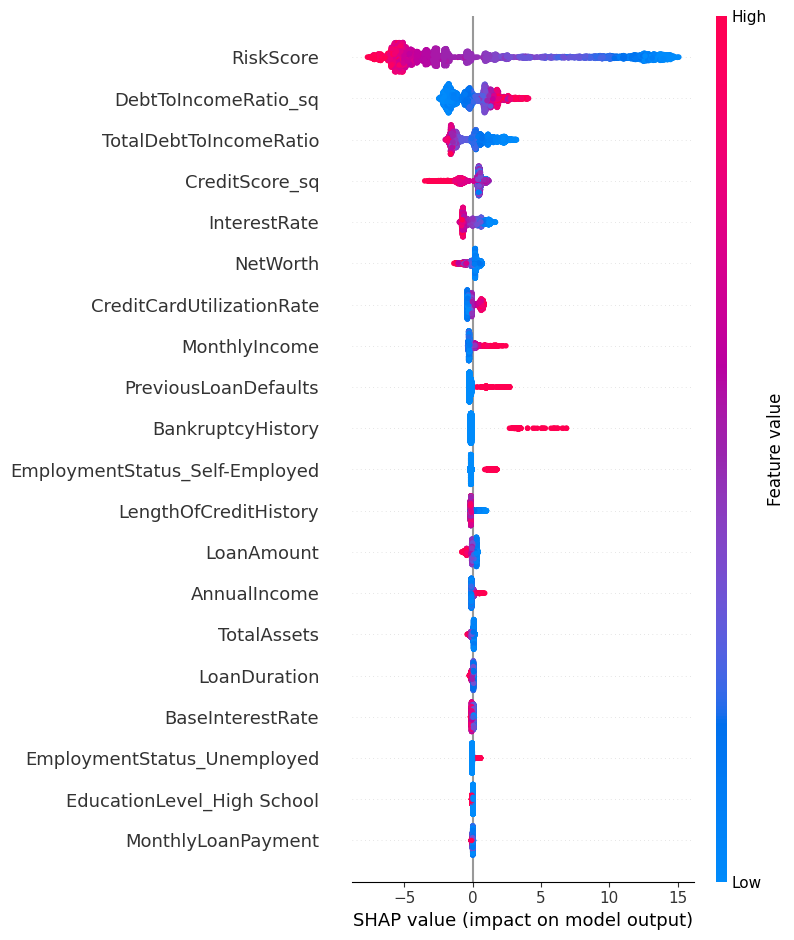

In [81]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns,
    show=False
)

plt.savefig(
    "SHAP_Summary_Plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

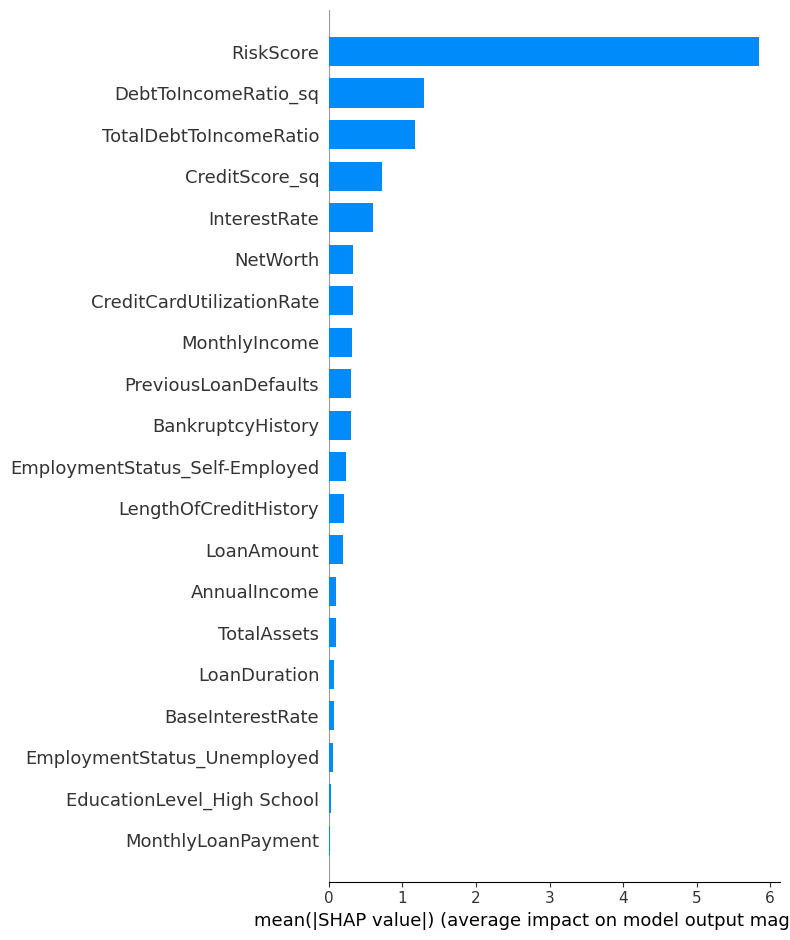

In [82]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns,
    plot_type="bar",
    show=False
)

plt.savefig(
    "SHAP_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [83]:
import joblib

joblib.dump(
    catboost_model,
    "final_catboost_model.pkl"
)

joblib.dump(
    scaler,
    "final_scaler.pkl"
)

print("CatBoost model and scaler saved successfully.")

CatBoost model and scaler saved successfully.


In [84]:
# Save preprocessing objects required for Streamlit

joblib.dump(ohe, "final_ohe.pkl")
joblib.dump(num_imp, "final_num_imputer.pkl")
joblib.dump(cat_imp, "final_cat_imputer.pkl")

# Save exact feature order used by the final CatBoost model
joblib.dump(X.columns.tolist(), "final_feature_columns.pkl")

print("All preprocessing files saved successfully.")
print("Number of final model features:", len(X.columns))

All preprocessing files saved successfully.
Number of final model features: 45


In [85]:
print("CatBoost:", os.path.exists("final_catboost_model.pkl"))
print("Scaler:", os.path.exists("final_scaler.pkl"))
print("OHE:", os.path.exists("final_ohe.pkl"))
print("Numerical Imputer:", os.path.exists("final_num_imputer.pkl"))
print("Categorical Imputer:", os.path.exists("final_cat_imputer.pkl"))
print("Feature Columns:", os.path.exists("final_feature_columns.pkl"))

CatBoost: True
Scaler: True
OHE: True
Numerical Imputer: True
Categorical Imputer: True
Feature Columns: True


In [86]:
joblib.dump(
    X_train_scaled,
    "final_X_train_scaled.pkl"
)

print("LIME training data saved successfully.")

LIME training data saved successfully.
